In [1]:
"""
NYC TAXI - PART 2: DATA VISUALIZATION 
This is comprehensive visualizations for urban mobility analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("NYC TAXI VISUALIZATION ANALYSIS - GROUP 9")
print("="*80)

NYC TAXI VISUALIZATION ANALYSIS - GROUP 9


In [2]:
# ============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================================
print("\n[STEP 1] Loading data...")
df = pd.read_csv('train.csv', parse_dates=['pickup_datetime', 'dropoff_datetime'])
df.head(5)




[STEP 1] Loading data...


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
len(df)

1458644

In [4]:
df = df.drop_duplicates()
print(' length of data after removal of duplicates')
len(df)


 length of data after removal of duplicates


1458644

In [5]:
from data_preprocessing import missing_data_threshold, missing_data_treatment, unique_value_treatment, feature_engineering, label_encoding

In [6]:
df = missing_data_threshold(df)

Deleted columns due to missing values > Threshold are --> []


In [7]:
# Clean data
print("\n[STEP 2] Cleaning data...")
df_clean = df[
    (df['pickup_latitude'].between(40.5, 41.0)) &
    (df['pickup_longitude'].between(-74.3, -73.7)) &
    (df['dropoff_latitude'].between(40.5, 41.0)) &
    (df['dropoff_longitude'].between(-74.3, -73.7)) &
    (df['trip_duration'] > 0) &
    (df['trip_duration'] <= 86400) &
    (df['passenger_count'].between(1, 6))
].copy()

print(f"✓ Cleaned: {len(df_clean):,} records ({len(df_clean)/len(df)*100:.1f}%)")


[STEP 2] Cleaning data...
✓ Cleaned: 1,457,578 records (99.9%)


In [8]:
# Feature engineering
print("\n[STEP 3] Engineering features...")
df_clean['trip_duration_minutes'] = df_clean['trip_duration'] / 60
df_clean['pickup_hour'] = df_clean['pickup_datetime'].dt.hour
df_clean['day_name'] = df_clean['pickup_datetime'].dt.day_name()
df_clean['day_of_week'] = df_clean['pickup_datetime'].dt.dayofweek
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)
df_clean['month_name'] = df_clean['pickup_datetime'].dt.month_name()



[STEP 3] Engineering features...


In [9]:
# The basic relation is shown by

# d =rθ
# {\displaystyle d=r\,\theta },
# where

# θ is the central angle between any two points on a sphere,
# d is the distance between the two points along a great circle of the sphere (see spherical distance),
# r is the radius of the sphere.
# The haversine formula allows the haversine of θ to be computed directly from the latitude (represented by φ) and longitude (represented by λ) of the two points:
# havθ = hav(Δφ)+cos(φ1)cos(φ2)hav⁡(Δλ)
# {\displaystyle \operatorname {hav} \theta =\operatorname {hav} \left(\Delta \varphi \right)+\cos \left(\varphi _{1}\right)\cos \left(\varphi _{2}\right)\operatorname {hav} \left(\Delta \lambda \right)}
# where

# φ1, φ2 are the latitude of point 1 and latitude of point 2,
# λ1, λ2 are the longitude of point 1 and longitude of point 2,Δφ=φ2−φ1
# {\displaystyle \Delta \varphi =\varphi _{2}-\varphi _{1}}, Δλ=λ2−λ1
# {\displaystyle \Delta \lambda =\lambda _{2}-\lambda _{1}}.

In [10]:
# Calculate trip distance (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_clean['trip_distance_km'] = haversine_distance(
    df_clean['pickup_latitude'],
    df_clean['pickup_longitude'],
    df_clean['dropoff_latitude'],
    df_clean['dropoff_longitude']
)


In [11]:
# Estimate fare
df_clean['estimated_fare'] = 2.5 + (df_clean['trip_distance_km'] * 1.56) + (df_clean['trip_duration_minutes'] * 0.35)

# Calculate speed
df_clean['speed_kmh'] = (df_clean['trip_distance_km'] / df_clean['trip_duration_minutes']) * 60

print("✓ Features: duration_min, hour, day, distance, fare, speed")

# Sample for geographic analysis (memory efficiency)
df_sample = df_clean.sample(n=min(100000, len(df_clean)), random_state=42)
print(f"✓ Sampled {len(df_sample):,} records for geographic analysis")

✓ Features: duration_min, hour, day, distance, fare, speed
✓ Sampled 100,000 records for geographic analysis


In [12]:
# ============================================================================
# SECTION 1: TEMPORAL DEMAND VISUALIZATIONS (30%)
# ============================================================================
print("\n[STEP 4] Creating temporal visualizations...")



[STEP 4] Creating temporal visualizations...


In [13]:
# Prepare aggregations
daily_trips = df_clean.groupby(df_clean['pickup_datetime'].dt.date).size()
daily_trips.index = pd.to_datetime(daily_trips.index)

hourly_avg = df_clean.groupby('pickup_hour').size() / len(daily_trips)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_hour_matrix = df_clean.groupby(['day_name', 'pickup_hour']).size().unstack(fill_value=0).reindex(day_order)

monthly_trips = df_clean.groupby('month_name').size()
print(f'{daily_trips}')


pickup_datetime
2016-01-01    7157
2016-01-02    6506
2016-01-03    6352
2016-01-04    6718
2016-01-05    7198
              ... 
2016-06-26    7081
2016-06-27    7303
2016-06-28    7247
2016-06-29    7621
2016-06-30    7583
Length: 182, dtype: int64


In [14]:
hourly_avg

pickup_hour
0     292.170330
1     211.659341
2     153.510989
3     114.686813
4      86.664835
5      82.318681
6     182.549451
7     305.285714
8     368.263736
9     371.576923
10    359.357143
11    376.054945
12    394.697802
13    392.521978
14    407.950549
15    394.324176
16    353.087912
17    419.950549
18    497.483516
19    495.956044
20    461.631868
21    462.142857
22    441.802198
23    383.021978
dtype: float64

In [15]:
day_hour_matrix

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Monday,4287,2572,1658,1225,1349,2143,5353,8611,10334,10002,...,9904,9949,9154,10848,12949,12225,11329,11179,9597,6951
Tuesday,4501,2571,1504,1011,1140,2122,5772,10048,11605,10944,...,10415,10093,8936,11081,13465,13036,12714,12678,11489,8650
Wednesday,5316,3129,1889,1280,1252,2086,5831,10341,11881,10989,...,10603,10025,8802,10856,13182,13687,13179,13423,12397,9722
Thursday,6283,3629,2142,1549,1384,2220,6046,10400,11933,10915,...,10920,10436,8755,10679,13528,14062,13624,14156,13405,11699
Friday,8768,5796,3942,2918,2313,2459,5544,9598,11461,10548,...,10951,10214,8817,11020,13403,14167,12821,12575,13279,13171
Saturday,11755,9975,8230,6030,3840,1996,2531,3722,5479,7877,...,10866,10861,9992,11262,12917,13046,11221,11370,12358,13163
Sunday,12265,10850,8574,6860,4495,1956,2147,2842,4331,6352,...,10588,10189,9806,10685,11098,10041,9129,8729,7883,6354


In [16]:
monthly_trips

month_name
April       251481
February    238140
January     229515
June        234122
March       256024
May         248296
dtype: int64

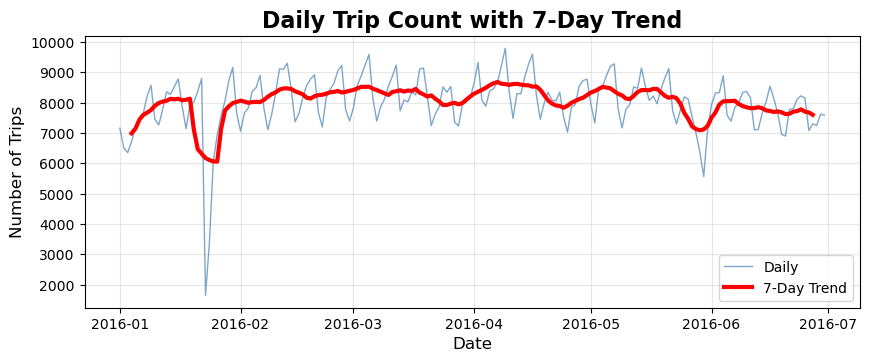

In [17]:
# Create figure
fig1 = plt.figure(figsize=(22, 12))

# Plot 1: Daily trip count with trend
ax1 = plt.subplot(3, 2, 1)
ax1.plot(daily_trips.index, daily_trips.values, linewidth=1, alpha=0.7, color='steelblue', label='Daily')
ma7 = daily_trips.rolling(window=7, center=True).mean()
ax1.plot(daily_trips.index, ma7.values, linewidth=3, color='red', label='7-Day Trend')
ax1.set_title('Daily Trip Count with 7-Day Trend', fontsize=16, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Trips', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

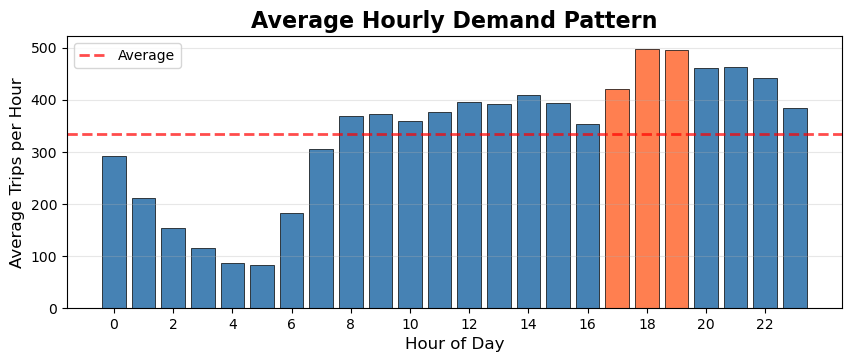

In [18]:
# Plot 2: Hourly demand
fig2 = plt.figure(figsize=(22, 12))
ax2 = plt.subplot(3, 2, 2)
colors_hourly = ['coral' if h in [17, 18, 19] else 'steelblue' for h in range(24)]
ax2.bar(range(24), hourly_avg.values, color=colors_hourly, edgecolor='black', linewidth=0.5)
ax2.set_title('Average Hourly Demand Pattern', fontsize=16, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=12)
ax2.set_ylabel('Average Trips per Hour', fontsize=12)
ax2.set_xticks(range(0, 24, 2))
ax2.axhline(hourly_avg.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Average')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')


Text(270.72222222222223, 0.5, 'Day of Week')

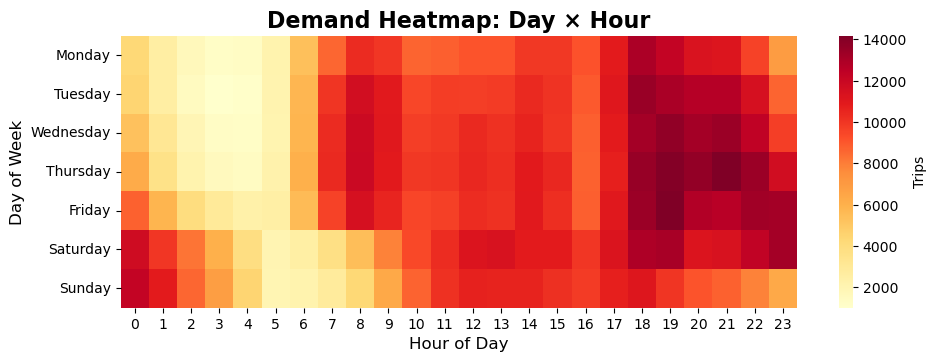

In [19]:
# Plot 3: Heatmap
fig3 = plt.figure(figsize=(24, 12))
ax3 = plt.subplot(3, 2, 3)
sns.heatmap(day_hour_matrix, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Trips'}, ax=ax3)
ax3.set_title('Demand Heatmap: Day × Hour', fontsize=16, fontweight='bold')
ax3.set_xlabel('Hour of Day', fontsize=12)
ax3.set_ylabel('Day of Week', fontsize=12)


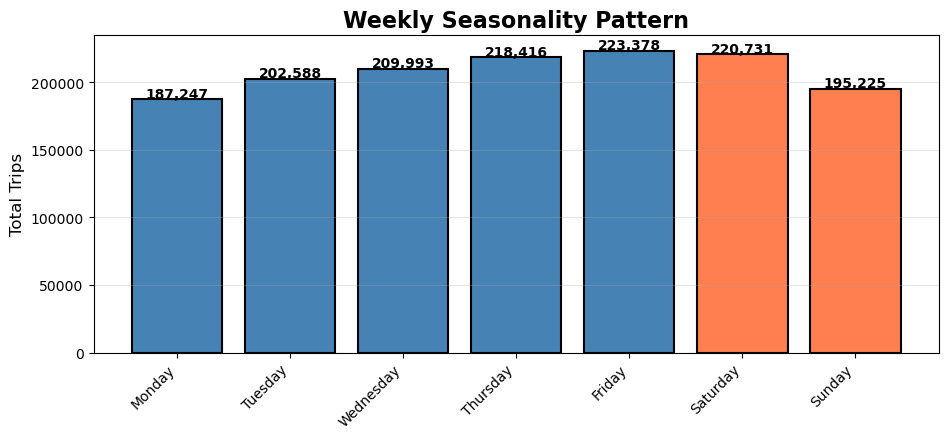

In [20]:
# Plot 4: Weekly seasonality
fig4 = plt.figure(figsize=(24, 14))
ax4 = plt.subplot(3, 2, 4)
weekly_avg = df_clean.groupby('day_name').size().reindex(day_order)
colors_weekly = ['steelblue']*5 + ['coral']*2
ax4.bar(range(7), weekly_avg.values, color=colors_weekly, edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(7))
ax4.set_xticklabels(day_order, rotation=45, ha='right')
ax4.set_title('Weekly Seasonality Pattern', fontsize=16, fontweight='bold')
ax4.set_ylabel('Total Trips', fontsize=12)
for i, v in enumerate(weekly_avg.values):
    ax4.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

In [48]:
monthly_trips

month_name
April       251481
February    238140
January     229515
June        234122
March       256024
May         248296
dtype: int64

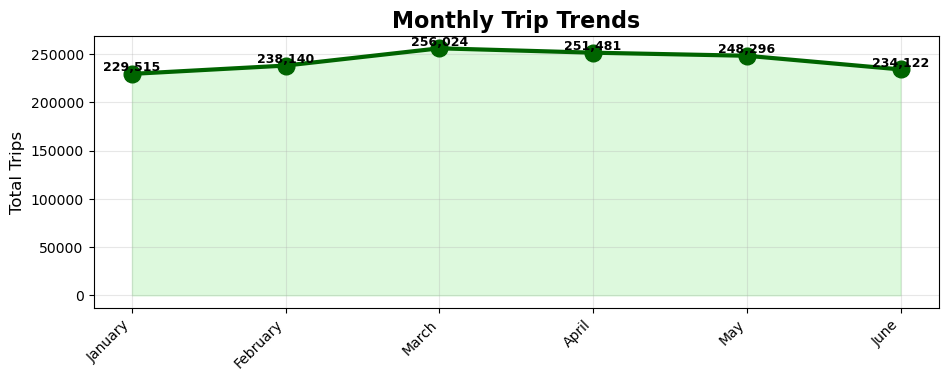

In [21]:
# Plot 5: Monthly trends
fig5 = plt.figure(figsize=(24, 12))
ax5 = plt.subplot(3, 2, 5)
month_order = ['January', 'February', 'March', 'April', 'May', 'June']
monthly_ordered = monthly_trips.reindex(month_order)
ax5.plot(range(len(monthly_ordered)), monthly_ordered.values, 'o-', linewidth=3, markersize=12, color='darkgreen')
ax5.fill_between(range(len(monthly_ordered)), monthly_ordered.values, alpha=0.3, color='lightgreen')
ax5.set_xticks(range(len(monthly_ordered)))
ax5.set_xticklabels(monthly_ordered.index, rotation=45, ha='right')
ax5.set_title('Monthly Trip Trends', fontsize=16, fontweight='bold')
ax5.set_ylabel('Total Trips', fontsize=12)
for i, v in enumerate(monthly_ordered.values):
    ax5.text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
ax5.grid(True, alpha=0.3)


  ✓ Saved: part2_temporal_demand.png


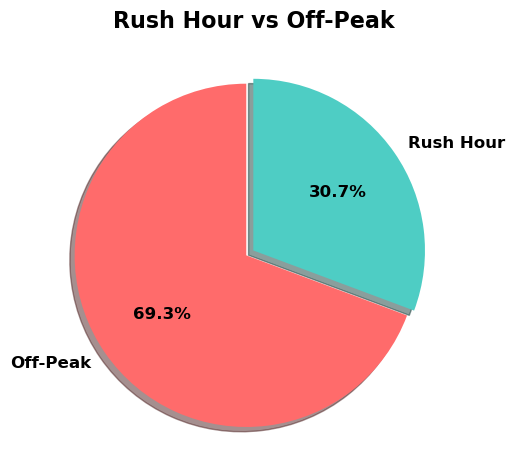

In [22]:
# Plot 6: Rush hour vs off-peak
fig6 = plt.figure(figsize=(24, 14))
ax6 = plt.subplot(3, 2, 6)
rush_hours = [7, 8, 9, 17, 18, 19]
df_clean['period'] = df_clean['pickup_hour'].apply(lambda x: 'Rush Hour' if x in rush_hours else 'Off-Peak')
period_counts = df_clean['period'].value_counts()
colors_pie = ['#ff6b6b', '#4ecdc4']
ax6.pie(period_counts.values, labels=period_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors_pie, explode=(0.05, 0), shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax6.set_title('Rush Hour vs Off-Peak', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('part2_temporal_demand.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: part2_temporal_demand.png")


In [49]:
period_counts

period
Off-Peak     1010128
Rush Hour     447450
Name: count, dtype: int64

In [23]:
# ============================================================================
# SECTION 2: GEOGRAPHIC & SPATIAL ANALYSIS (25%)
# ============================================================================
print("\n[STEP 5] Creating geographic visualizations...")



[STEP 5] Creating geographic visualizations...


In [54]:
# Borough assignment
def assign_borough(lat, lon):
    if lat > 40.85: return 'Bronx'
    elif lon < -74.0 and lat < 40.72: return 'Manhattan Downtown'
    elif lon < -73.94 and lat > 40.72: return 'Manhattan Midtown/Uptown'
    elif lon > -73.94 and lat > 40.7 and lat < 40.8: return 'Queens'
    elif lat < 40.65: return 'Brooklyn'
    else: return 'Other'

df_sample['pickup_borough'] = df_sample.apply(
    lambda row: assign_borough(row['pickup_latitude'], row['pickup_longitude']), axis=1
)
df_sample['dropoff_borough'] = df_sample.apply(
    lambda row: assign_borough(row['dropoff_latitude'], row['dropoff_longitude']), axis=1
)

df_sample.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,day_of_week,is_weekend,month_name,trip_distance_km,estimated_fare,speed_kmh,pickup_borough,dropoff_borough,to_airport,from_airport
1081394,id2553520,1,2016-03-07 22:02:14,2016-03-07 22:08:51,1,-73.986107,40.762436,-73.971146,40.782791,N,...,0,0,March,2.590412,8.856876,23.489883,Manhattan Midtown/Uptown,Manhattan Midtown/Uptown,False,False
338945,id0461609,1,2016-04-17 10:33:57,2016-04-17 11:05:27,1,-73.972542,40.608910,-73.972153,40.608982,N,...,6,1,April,0.033820,13.577760,0.064420,Brooklyn,Brooklyn,False,False
210947,id3474978,1,2016-06-17 23:29:11,2016-06-17 23:45:17,1,-73.980125,40.765175,-73.999077,40.739407,N,...,4,0,June,3.279989,13.251783,12.223562,Manhattan Midtown/Uptown,Manhattan Midtown/Uptown,False,False
1330041,id3932857,1,2016-01-07 05:03:17,2016-01-07 05:10:42,1,-73.984161,40.769196,-73.973343,40.755520,N,...,3,0,January,1.772745,7.861316,14.341309,Manhattan Midtown/Uptown,Manhattan Midtown/Uptown,False,False
598695,id2069998,1,2016-01-23 02:41:03,2016-01-23 02:55:27,1,-73.990524,40.686703,-73.987640,40.663895,N,...,5,1,January,2.547777,11.514532,10.615737,Other,Other,False,False


(40.6, 40.9)

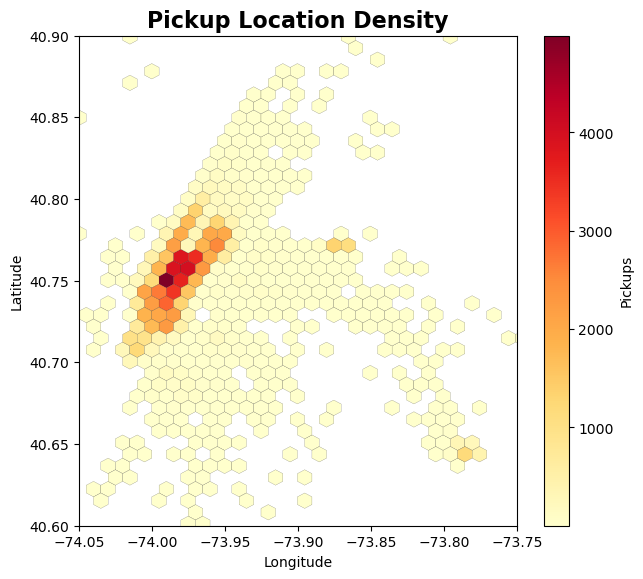

In [25]:
# Plot 1: Pickup density (hexbin)
fig7 = plt.figure(figsize=(24, 14))
ax1 = plt.subplot(2, 3, 1)
hb = ax1.hexbin(df_sample['pickup_longitude'], df_sample['pickup_latitude'],
                gridsize=50, cmap='YlOrRd', mincnt=1, edgecolors='black', linewidths=0.1)
ax1.set_title('Pickup Location Density', fontsize=16, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(hb, ax=ax1, label='Pickups')
ax1.set_xlim(-74.05, -73.75)
ax1.set_ylim(40.6, 40.9)


(40.6, 40.9)

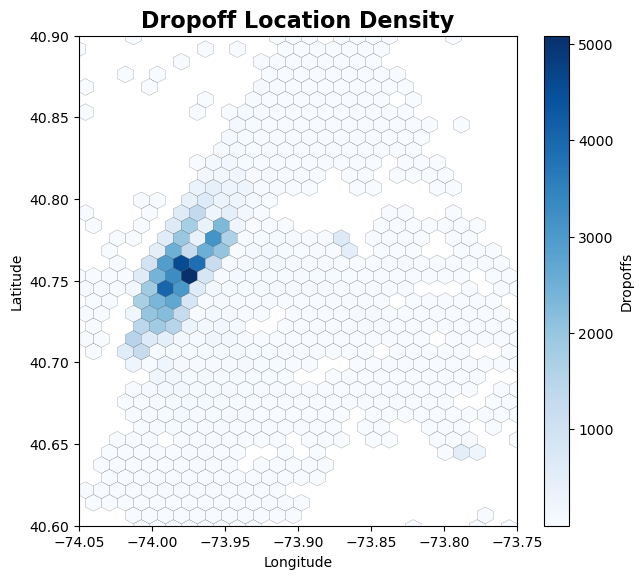

In [26]:
# Plot 2: Dropoff density
fig8 = plt.figure(figsize=(24, 14))
ax2 = plt.subplot(2, 3, 2)
hb2 = ax2.hexbin(df_sample['dropoff_longitude'], df_sample['dropoff_latitude'],
                 gridsize=50, cmap='Blues', mincnt=1, edgecolors='black', linewidths=0.1)
ax2.set_title('Dropoff Location Density', fontsize=16, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
plt.colorbar(hb2, ax=ax2, label='Dropoffs')
ax2.set_xlim(-74.05, -73.75)
ax2.set_ylim(40.6, 40.9)


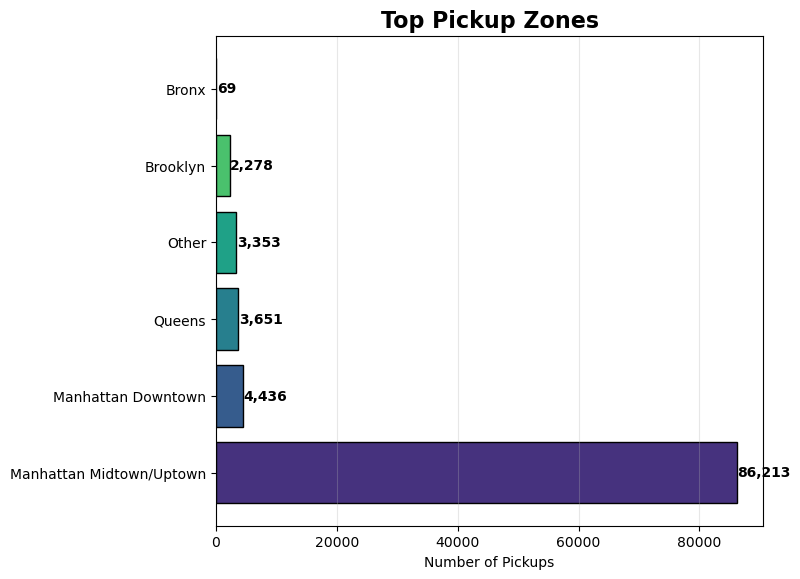

In [27]:
# Plot 3: Top pickup zones
fig9 = plt.figure(figsize=(24, 14))
ax3 = plt.subplot(2, 3, 3)
top_pickup = df_sample['pickup_borough'].value_counts().head(10)
colors_pickup = sns.color_palette("viridis", len(top_pickup))
ax3.barh(range(len(top_pickup)), top_pickup.values, color=colors_pickup, edgecolor='black')
ax3.set_yticks(range(len(top_pickup)))
ax3.set_yticklabels(top_pickup.index)
ax3.set_xlabel('Number of Pickups')
ax3.set_title('Top Pickup Zones', fontsize=16, fontweight='bold')
for i, v in enumerate(top_pickup.values):
    ax3.text(v + 100, i, f'{v:,}', va='center', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')


Text(0.5, 1.0, 'Borough-wise Distribution')

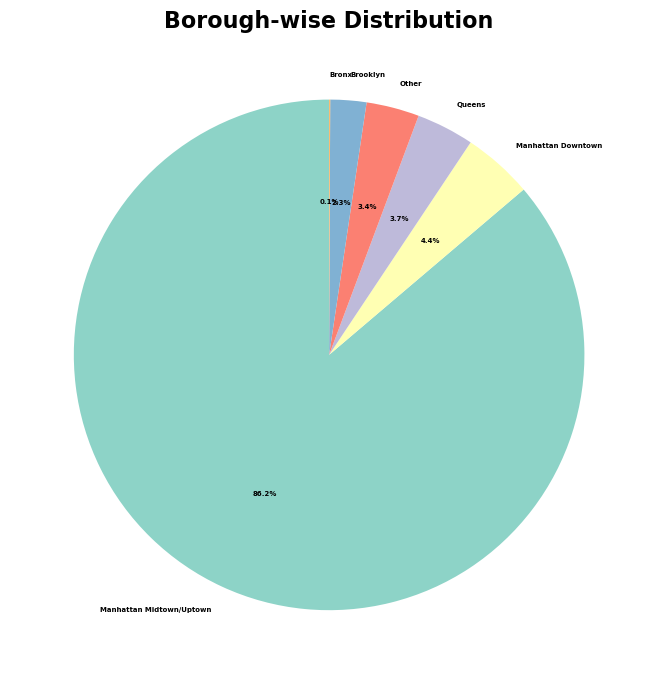

In [63]:
# Plot 4: Borough distribution
fig10 = plt.figure(figsize=(28, 20))
ax4 = plt.subplot(2, 3, 4)
borough_trips = df_sample['pickup_borough'].value_counts()
colors_borough = sns.color_palette("Set3", len(borough_trips))
ax4.pie(borough_trips.values, labels=borough_trips.index, autopct='%1.1f%%',
        startangle=90, colors=colors_borough, textprops={'fontsize': 5, 'fontweight': 'bold'})
ax4.set_title('Borough-wise Distribution', fontsize=16, fontweight='bold')

In [58]:
borough_trips

pickup_borough
Manhattan Midtown/Uptown    86213
Manhattan Downtown           4436
Queens                       3651
Other                        3353
Brooklyn                     2278
Bronx                          69
Name: count, dtype: int64

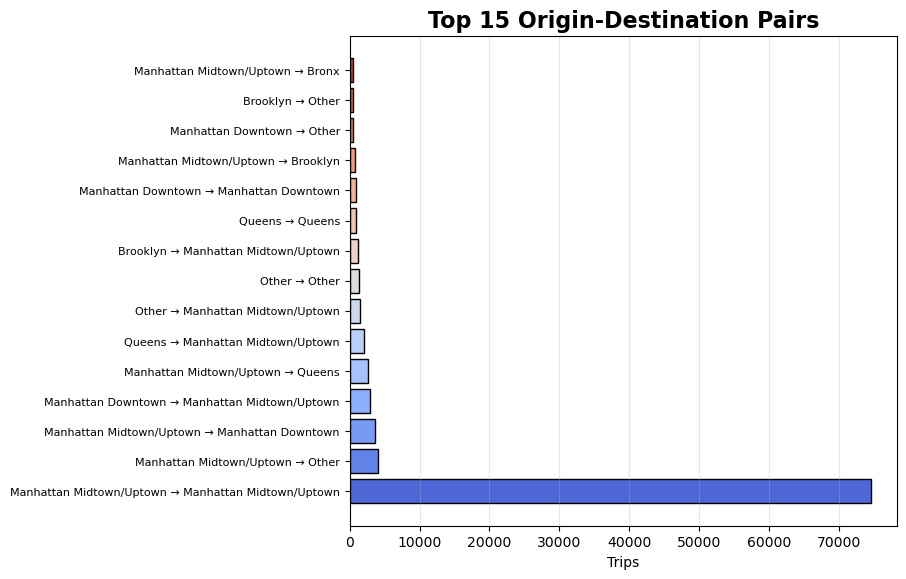

In [29]:
# Plot 5: Origin-Destination pairs
fig11 = plt.figure(figsize=(24, 14))
ax5 = plt.subplot(2, 3, 5)
od_pairs = df_sample.groupby(['pickup_borough', 'dropoff_borough']).size().nlargest(15)
od_df = od_pairs.reset_index(name='trips')
od_df['route'] = od_df['pickup_borough'] + ' → ' + od_df['dropoff_borough']
colors_od = sns.color_palette("coolwarm", len(od_df))
ax5.barh(range(len(od_df)), od_df['trips'], color=colors_od, edgecolor='black')
ax5.set_yticks(range(len(od_df)))
ax5.set_yticklabels(od_df['route'], fontsize=8)
ax5.set_xlabel('Trips')
ax5.set_title('Top 15 Origin-Destination Pairs', fontsize=16, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')


  ✓ Saved: part2_geographic_analysis.png


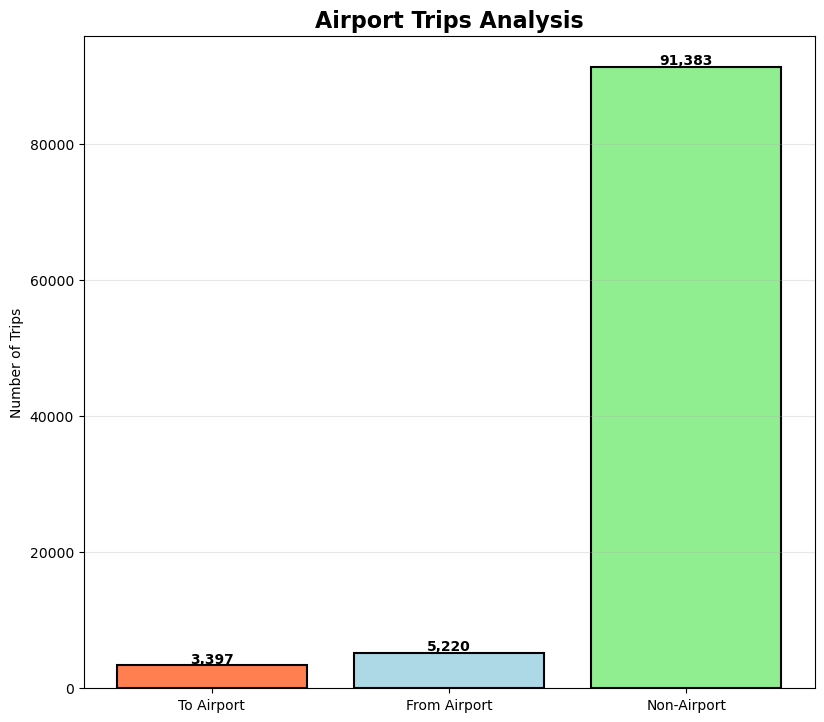

In [30]:
# Plot 6: Airport trips
fig12 = plt.figure(figsize=(24, 14))
ax6 = plt.subplot(2, 3, 6)
def is_airport(lat, lon):
    jfk_dist = np.sqrt((lat - 40.64)**2 + (lon - (-73.78))**2)
    lga_dist = np.sqrt((lat - 40.77)**2 + (lon - (-73.87))**2)
    return (jfk_dist < 0.05) or (lga_dist < 0.05)

df_sample['to_airport'] = df_sample.apply(lambda r: is_airport(r['dropoff_latitude'], r['dropoff_longitude']), axis=1)
df_sample['from_airport'] = df_sample.apply(lambda r: is_airport(r['pickup_latitude'], r['pickup_longitude']), axis=1)

airport_stats = pd.DataFrame({
    'Category': ['To Airport', 'From Airport', 'Non-Airport'],
    'Count': [df_sample['to_airport'].sum(), df_sample['from_airport'].sum(),
              len(df_sample) - df_sample['to_airport'].sum() - df_sample['from_airport'].sum()]
})
ax6.bar(airport_stats['Category'], airport_stats['Count'],
        color=['coral', 'lightblue', 'lightgreen'], edgecolor='black', linewidth=1.5)
ax6.set_ylabel('Number of Trips')
ax6.set_title('Airport Trips Analysis', fontsize=16, fontweight='bold')
for i, v in enumerate(airport_stats['Count']):
    ax6.text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part2_geographic_analysis.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: part2_geographic_analysis.png")


In [31]:
# ============================================================================
# SECTION 3: TRIP CHARACTERISTICS ANALYSIS (25%)
# ============================================================================
print("\n[STEP 6] Creating trip characteristics visualizations...")


[STEP 6] Creating trip characteristics visualizations...


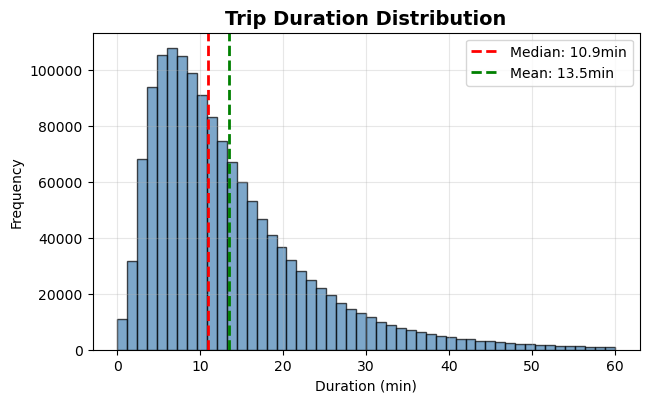

In [32]:
fig13 = plt.figure(figsize=(24, 14))

# Plot 1: Duration distribution
ax1 = plt.subplot(3, 3, 1)
duration_filt = df_clean[df_clean['trip_duration_minutes'] <= 60]['trip_duration_minutes']
ax1.hist(duration_filt, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(duration_filt.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {duration_filt.median():.1f}min')
ax1.axvline(duration_filt.mean(), color='green', linestyle='--', linewidth=2,
            label=f'Mean: {duration_filt.mean():.1f}min')
ax1.set_xlabel('Duration (min)')
ax1.set_ylabel('Frequency')
ax1.set_title('Trip Duration Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)


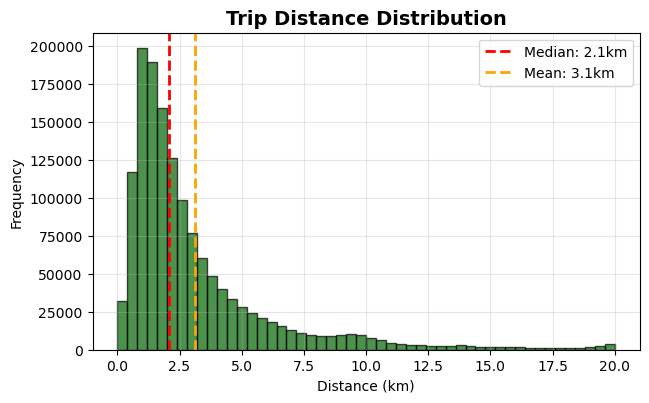

In [33]:
# Plot 2: Distance distribution
fig14 = plt.figure(figsize=(24, 14))
ax2 = plt.subplot(3, 3, 2)
distance_filt = df_clean[df_clean['trip_distance_km'] <= 20]['trip_distance_km']
ax2.hist(distance_filt, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
ax2.axvline(distance_filt.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {distance_filt.median():.1f}km')
ax2.axvline(distance_filt.mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean: {distance_filt.mean():.1f}km')
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Frequency')
ax2.set_title('Trip Distance Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

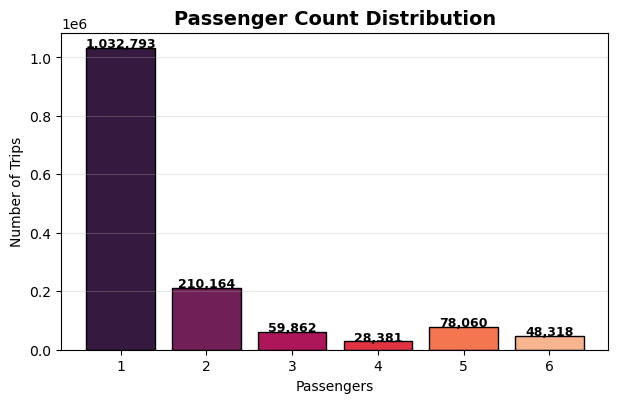

In [34]:
# Plot 3: Passenger count
fig15 = plt.figure(figsize=(24, 14))
ax3 = plt.subplot(3, 3, 3)
passenger_counts = df_clean['passenger_count'].value_counts().sort_index()
colors_pass = sns.color_palette("rocket", len(passenger_counts))
ax3.bar(passenger_counts.index, passenger_counts.values, color=colors_pass, edgecolor='black', linewidth=1)
ax3.set_xlabel('Passengers')
ax3.set_ylabel('Number of Trips')
ax3.set_title('Passenger Count Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(passenger_counts.values):
    ax3.text(passenger_counts.index[i], v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')


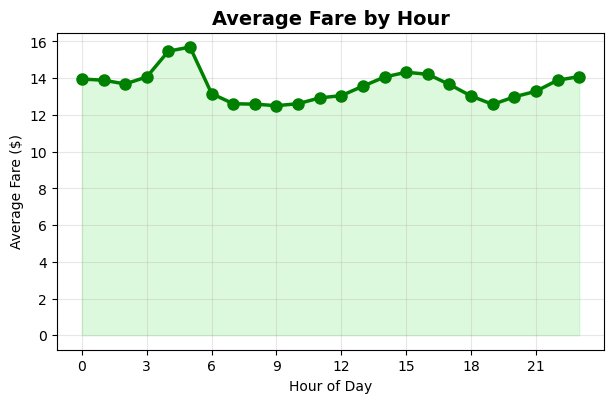

In [35]:
# Plot 4: Fare by hour
fig4 = plt.figure(figsize=(24, 14))
ax4 = plt.subplot(3, 3, 4)
fare_by_hour_avg = df_clean.groupby('pickup_hour')['estimated_fare'].mean()
ax4.plot(range(24), fare_by_hour_avg.values, 'o-', linewidth=2.5, markersize=8, color='green')
ax4.fill_between(range(24), fare_by_hour_avg.values, alpha=0.3, color='lightgreen')
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Average Fare ($)')
ax4.set_title('Average Fare by Hour', fontsize=14, fontweight='bold')
ax4.set_xticks(range(0, 24, 3))
ax4.grid(True, alpha=0.3)

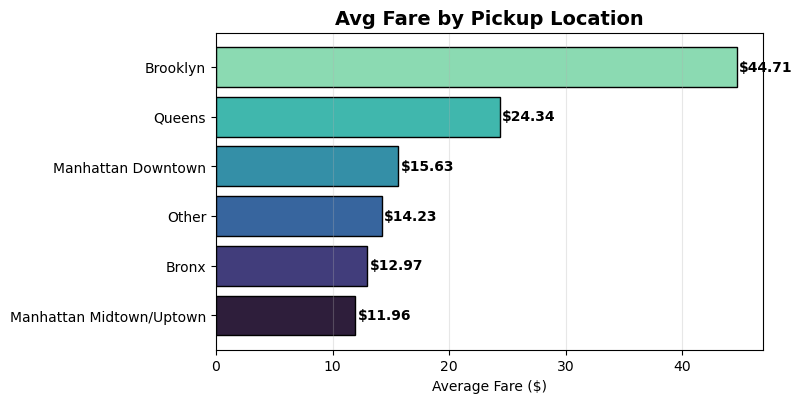

In [36]:
# Plot 5: Fare by borough
fig5 = plt.figure(figsize=(24, 14))
ax5 = plt.subplot(3, 3, 5)
avg_fare_borough = df_sample.groupby('pickup_borough')['estimated_fare'].mean().sort_values()
colors_fare = sns.color_palette("mako", len(avg_fare_borough))
ax5.barh(range(len(avg_fare_borough)), avg_fare_borough.values, color=colors_fare, edgecolor='black')
ax5.set_yticks(range(len(avg_fare_borough)))
ax5.set_yticklabels(avg_fare_borough.index)
ax5.set_xlabel('Average Fare ($)')
ax5.set_title('Avg Fare by Pickup Location', fontsize=14, fontweight='bold')
for i, v in enumerate(avg_fare_borough.values):
    ax5.text(v + 0.2, i, f'${v:.2f}', va='center', fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')


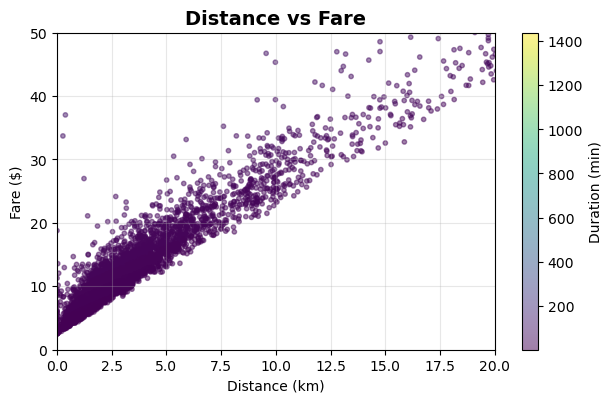

In [37]:
# Plot 6: Distance vs fare scatter
fig6 = plt.figure(figsize=(24, 14))
ax6 = plt.subplot(3, 3, 6)
scatter_sample = df_clean.sample(n=5000, random_state=42)
scatter = ax6.scatter(scatter_sample['trip_distance_km'], scatter_sample['estimated_fare'],
                      c=scatter_sample['trip_duration_minutes'], cmap='viridis', alpha=0.5, s=10)
ax6.set_xlabel('Distance (km)')
ax6.set_ylabel('Fare ($)')
ax6.set_title('Distance vs Fare', fontsize=14, fontweight='bold')
ax6.set_xlim(0, 20)
ax6.set_ylim(0, 50)
plt.colorbar(scatter, ax=ax6, label='Duration (min)')
ax6.grid(True, alpha=0.3)

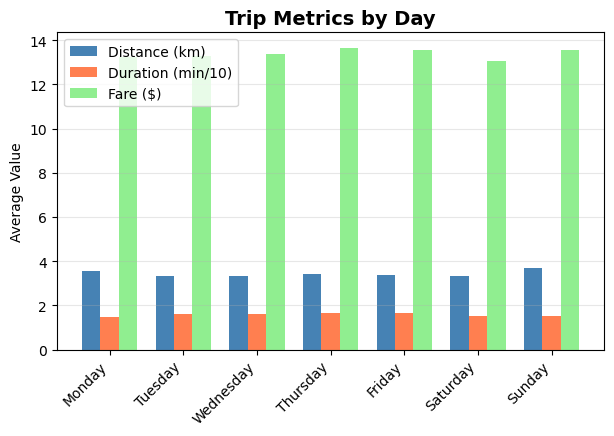

In [38]:
# Plot 7: Daily metrics
fig7 = plt.figure(figsize=(24, 14))
ax7 = plt.subplot(3, 3, 7)
daily_stats = df_clean.groupby('day_name').agg({
    'trip_distance_km': 'mean',
    'trip_duration_minutes': 'mean',
    'estimated_fare': 'mean'
}).reindex(day_order)
x = np.arange(7)
width = 0.25
ax7.bar(x - width, daily_stats['trip_distance_km'], width, label='Distance (km)', color='steelblue')
ax7.bar(x, daily_stats['trip_duration_minutes']/10, width, label='Duration (min/10)', color='coral')
ax7.bar(x + width, daily_stats['estimated_fare'], width, label='Fare ($)', color='lightgreen')
ax7.set_xticks(x)
ax7.set_xticklabels(day_order, rotation=45, ha='right')
ax7.set_ylabel('Average Value')
ax7.set_title('Trip Metrics by Day', fontsize=14, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

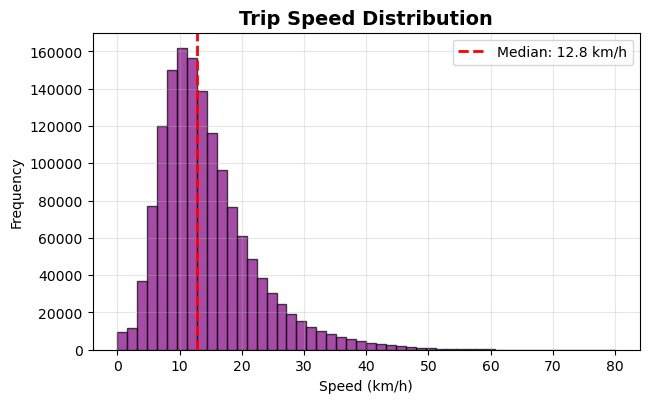

In [39]:
# Plot 8: Speed distribution
fig8 = plt.figure(figsize=(24, 14))
ax8 = plt.subplot(3, 3, 8)
speed_filt = df_clean[(df_clean['speed_kmh'] > 0) & (df_clean['speed_kmh'] <= 80)]['speed_kmh']
ax8.hist(speed_filt, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax8.axvline(speed_filt.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {speed_filt.median():.1f} km/h')
ax8.set_xlabel('Speed (km/h)')
ax8.set_ylabel('Frequency')
ax8.set_title('Trip Speed Distribution', fontsize=14, fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)

  ✓ Saved: part2_trip_characteristics.png


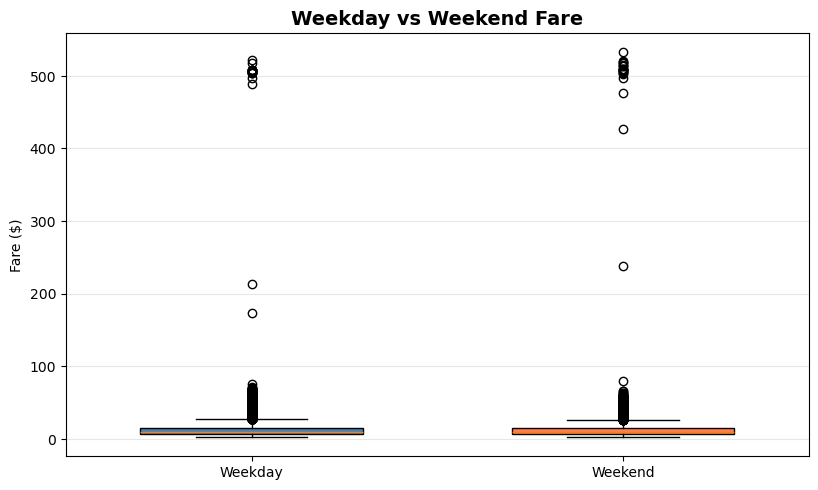

In [40]:
# Plot 9: Weekday vs Weekend boxplot
fig9 = plt.figure(figsize=(24, 14))
ax9 = plt.subplot(3, 3, 9)
weekday_data = df_clean[df_clean['is_weekend'] == 0]['estimated_fare'].sample(10000)
weekend_data = df_clean[df_clean['is_weekend'] == 1]['estimated_fare'].sample(10000)
bp = ax9.boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'],
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax9.set_ylabel('Fare ($)')
ax9.set_title('Weekday vs Weekend Fare', fontsize=14, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part2_trip_characteristics.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: part2_trip_characteristics.png")


In [41]:
# ============================================================================
# EXPORT KEY STATISTICS
# ============================================================================
print("\n[STEP 7] Exporting summary statistics...")



[STEP 7] Exporting summary statistics...


In [42]:
# Daily summary
daily_summary = pd.DataFrame({
    'date': daily_trips.index,
    'trips': daily_trips.values
})
daily_summary.to_csv('daily_trip_summary.csv', index=False)



In [43]:
# Hourly pattern
hourly_pattern = pd.DataFrame({
    'hour': range(24),
    'avg_trips': hourly_avg.values
})
hourly_pattern.to_csv('hourly_pattern.csv', index=False)


In [44]:
# Borough statistics
borough_stats = df_sample.groupby('pickup_borough').agg({
    'trip_distance_km': 'mean',
    'trip_duration_minutes': 'mean',
    'estimated_fare': 'mean'
}).reset_index()
borough_stats.columns = ['borough', 'avg_distance_km', 'avg_duration_min', 'avg_fare_usd']
borough_stats['total_trips'] = df_sample['pickup_borough'].value_counts().values
borough_stats.to_csv('borough_statistics.csv', index=False)


In [45]:
print("  ✓ daily_trip_summary.csv")
print("  ✓ hourly_pattern.csv")
print("  ✓ borough_statistics.csv")

# ============================================================================
#  SUMMARY
# ============================================================================
print("\n" + "="*80)
print("KEY INSIGHTS - DATA VISUALIZATION:")
print("="*80)

print(f"\n📊 TEMPORAL PATTERNS:")
print(f"   • Peak hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.0f} trips/hour avg)")
print(f"   • Busiest day: {weekly_avg.idxmax()} ({weekly_avg.max():,} trips)")
print(f"   • Quietest day: {weekly_avg.idxmin()} ({weekly_avg.min():,} trips)")
print(f"   • Rush hour share: {period_counts['Rush Hour'] / period_counts.sum() * 100:.1f}%")

print(f"\n🗺️ GEOGRAPHIC PATTERNS:")
print(f"   • Top pickup zone: {top_pickup.index[0]} ({top_pickup.values[0]:,} trips)")
print(f"   • Airport trips: {(df_sample['to_airport'].sum() + df_sample['from_airport'].sum()) / len(df_sample) * 100:.1f}%")
print(f"   • Manhattan share: {borough_trips.get('Manhattan Midtown/Uptown', 0) / borough_trips.sum() * 100:.1f}%")

print(f"\n📏 TRIP CHARACTERISTICS:")
print(f"   • Median duration: {duration_filt.median():.1f} minutes")
print(f"   • Median distance: {distance_filt.median():.1f} km")
print(f"   • Average fare: ${df_clean['estimated_fare'].mean():.2f}")
print(f"   • Median speed: {speed_filt.median():.1f} km/h")
print(f"   • Solo travelers: {(passenger_counts[1] / passenger_counts.sum() * 100):.1f}%")

print("\n" + "="*80)
print("✅ PART 2 COMPLETE!")
print("="*80)
print("\nGenerated Files:")
print("  • part2_temporal_demand.png")
print("  • part2_geographic_analysis.png")
print("  • part2_trip_characteristics.png")
print("  • daily_trip_summary.csv")
print("  • hourly_pattern.csv")
print("  • borough_statistics.csv")
print("\n" + "="*80)

  ✓ daily_trip_summary.csv
  ✓ hourly_pattern.csv
  ✓ borough_statistics.csv

KEY INSIGHTS - DATA VISUALIZATION:

📊 TEMPORAL PATTERNS:
   • Peak hour: 18:00 (497 trips/hour avg)
   • Busiest day: Friday (223,378 trips)
   • Quietest day: Monday (187,247 trips)
   • Rush hour share: 30.7%

🗺️ GEOGRAPHIC PATTERNS:
   • Top pickup zone: Manhattan Midtown/Uptown (86,213 trips)
   • Airport trips: 8.6%
   • Manhattan share: 86.2%

📏 TRIP CHARACTERISTICS:
   • Median duration: 10.9 minutes
   • Median distance: 2.1 km
   • Average fare: $13.39
   • Median speed: 12.8 km/h
   • Solo travelers: 70.9%

✅ PART 2 COMPLETE!

Generated Files:
  • part2_temporal_demand.png
  • part2_geographic_analysis.png
  • part2_trip_characteristics.png
  • daily_trip_summary.csv
  • hourly_pattern.csv
  • borough_statistics.csv

